# Training Loop Example

In this notebook, we implement a training loop for a basic transformer model in pyTorch on the tiny shakespeare data set, as a hommage to nanoGPT from Andrej Karpathy's brilliant [Neural Networks: Zero to Hero](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ) series.

## Imports and Setup

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from matplotlib.pylab import plt

In [21]:
from adam import Adam

In [22]:
file_path = "../data/input.txt"

with open(file_path, "r") as f:
    dataset = list(f.read())

## Dataset Preparation

In [23]:
chars = sorted(set(dataset))
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {ctoi[c]:c for c in ctoi.keys()}

In [24]:
encode = lambda s: [ctoi[c] for c in s]
decode = lambda s: "".join([itoc[i] for i in s])

In [25]:
data = encode(dataset)
data_tensor = torch.tensor(data, dtype=torch.long)
data_size = data_tensor.size(dim=0)

In [26]:
split = round(data_size*0.9)
data_train = data_tensor[:split]
data_val = data_tensor[split:]

In [27]:
len_train = data_train.size(dim=0)
len_val = data_val.size(dim=0)

In [28]:
print(f"length of training set: {len_train}")
print(f"length of validation set: {len_val}")

length of training set: 1003855
length of validation set: 111539


## Model Initialization

In [29]:
class Model(nn.Module):

    def __init__(self, block_size: int, vocab_size: int, d_model: int, nhead: int, num_layers: int):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, d_model)

        self.positional_embedding = nn.Embedding(block_size, d_model)
        self.causal_mask = torch.triu(torch.ones(block_size, block_size), diagonal=1).bool()

        self.encoding_layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(self.encoding_layer, num_layers, enable_nested_tensor=False)

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, inputs: torch.Tensor):
        embeddings = self.token_embedding(inputs)
        pos_tensor = torch.tensor(range(self.block_size), dtype=torch.long)
        pos_embeddings = self.positional_embedding(pos_tensor)
        embeddings += pos_embeddings

        transformer_outputs = self.transformer(embeddings, self.causal_mask)
        logits = self.lm_head(transformer_outputs)
        return logits

In [30]:
block_size = 128
vocab_size = len(chars)
d_model = 128
nhead = 4
num_layers = 4

## Training Loop (our Adam)

### Initialization and Setup

In [31]:
model = Model(block_size, vocab_size, d_model, nhead, num_layers)
model.train()

Model(
  (token_embedding): Embedding(65, 128)
  (positional_embedding): Embedding(128, 128)
  (encoding_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_feature

In [32]:
params = model.parameters()
optim = Adam(params, lr=0.001)

In [33]:
losses = []

In [34]:
num_iters = 1000000

### Actual training loop

In [35]:
for _ in tqdm(range(num_iters)):
    sequence_idx = np.random.randint(0, len_train - block_size - 1)
    x = data_train[sequence_idx : sequence_idx + block_size]
    y = data_train[sequence_idx + 1 : sequence_idx + block_size + 1]
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    losses.append(loss.item())

    optim.zero_grad()
    loss.backward()
    optim.step()

100%|██████████| 1000000/1000000 [4:02:42<00:00, 68.67it/s] 


Text(0, 0.5, 'Loss')

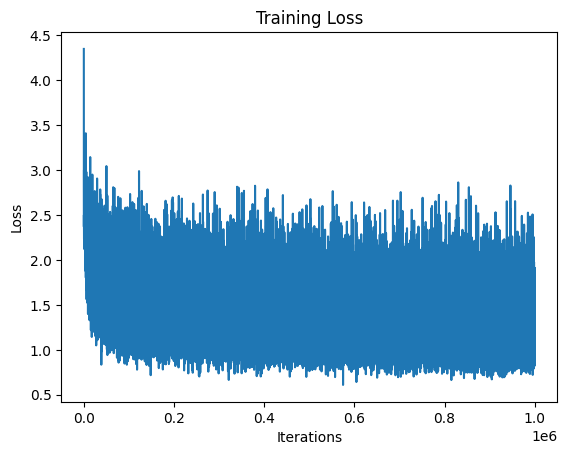

In [36]:
plt.plot(range(1,num_iters + 1), losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

Note: we attribute the high variance of the per-iteration loss to the fact that the model is trained on single sequences, so batch size 1.
In our view, this is sufficient for the purposes of this demonstration.

### Validation

In [38]:
model.eval()

val_losses = []

eval_iters = 500

with torch.no_grad():
    for _ in tqdm(range(eval_iters)):
        sequence_idx = np.random.randint(0, len_val - block_size - 1)
        x = data_val[sequence_idx : sequence_idx + block_size]
        y = data_val[sequence_idx + 1 : sequence_idx + block_size + 1]
        
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        val_losses.append(loss.item())

model.train()

val_loss = np.average(val_losses)
print(f"average validation loss with {eval_iters} iterations: {val_loss}")

100%|██████████| 500/500 [00:00<00:00, 590.33it/s]

average validation loss with 500 iterations: 1.505313303232193


## Sampling

In [41]:
text_len = 400

#TODO @dkoe00: make input sequence length of model dynamic instead of padding here
prompt = "To be"
padding = " "
padded_prompt = padding * (block_size - len(prompt)) + prompt
text = torch.tensor(encode(padded_prompt), dtype=torch.long)

for _ in tqdm(range(text_len)):
    context = text[-block_size:]
    logits = model(context)
    next_logits = logits[-1]
    probs = F.softmax(next_logits)
    idx = torch.multinomial(probs, num_samples=1)
    text = torch.cat([text, idx])

text = decode(text.tolist())
print(text)

  0%|          | 0/400 [00:00<?, ?it/s]/var/folders/xk/wh_dv4fd785263srbm07380m0000gn/T/ipykernel_49412/3085424452.py:13: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(next_logits)
100%|██████████| 400/400 [00:02<00:00, 149.84it/s]

                                                                                                                           To bell.

BO in HeNSIO:
Banish, hold somnos the profesticy
honour's crown the cose of be the war; Doubt, therefore,
Myself a be lear down lentness
And vex'd of head the cruels meaning; to thy siler,
Prace there like a measure from so;
And true of her not thine own blood
In stop a ledinous best ral spludel,
Ourssaid behold mens to hell-brawd. Two heart, whence o'er'd shall witdings?
Liege adders, if it 


## Training Loop (torch.optim.Adam)

### Initialization and Setup

In [ ]:
model2 = Model(block_size, vocab_size, d_model, nhead, num_layers)
model2.train()

Model(
  (token_embedding): Embedding(65, 128)
  (positional_embedding): Embedding(128, 128)
  (encoding_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_feature

In [ ]:
params = model2.parameters()
optim = torch.optim.Adam(params, lr=0.001)

In [ ]:
losses = []

In [ ]:
num_iters = 1000000

### Actual training loop

In [ ]:
for _ in tqdm(range(num_iters)):
    sequence_idx = np.random.randint(0, len_train - block_size - 1)
    x = data_train[sequence_idx : sequence_idx + block_size]
    y = data_train[sequence_idx + 1 : sequence_idx + block_size + 1]
    
    logits = model2(x)
    loss = F.cross_entropy(logits, y)

    losses.append(loss.item())

    optim.zero_grad()
    loss.backward()
    optim.step()

100%|██████████| 1000000/1000000 [4:02:42<00:00, 68.67it/s] 


Text(0, 0.5, 'Loss')

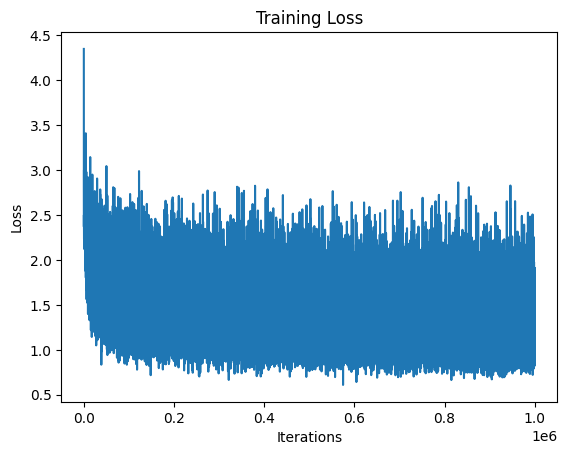

In [ ]:
plt.plot(range(1,num_iters + 1), losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

Note: we attribute the high variance of the per-iteration loss to the fact that the model is trained on single sequences, so batch size 1.
In our view, this is sufficient for the purposes of this demonstration.

### Validation

In [ ]:
model2.eval()

val_losses = []

eval_iters = 500

with torch.no_grad():
    for _ in tqdm(range(eval_iters)):
        sequence_idx = np.random.randint(0, len_val - block_size - 1)
        x = data_val[sequence_idx : sequence_idx + block_size]
        y = data_val[sequence_idx + 1 : sequence_idx + block_size + 1]
        
        logits = model2(x)
        loss = F.cross_entropy(logits, y)

        val_losses.append(loss.item())

model2.train()

val_loss = np.average(val_losses)
print(f"average validation loss with {eval_iters} iterations: {val_loss}")

100%|██████████| 500/500 [00:00<00:00, 590.33it/s]

average validation loss with 500 iterations: 1.505313303232193


## Sampling

In [ ]:
text_len = 400

#TODO @dkoe00: make input sequence length of model dynamic instead of padding here
prompt = "To be"
padding = " "
padded_prompt = padding * (block_size - len(prompt)) + prompt
text2 = torch.tensor(encode(padded_prompt), dtype=torch.long)

for _ in tqdm(range(text_len)):
    context = text2[-block_size:]
    logits = model(context)
    next_logits = logits[-1]
    probs = F.softmax(next_logits)
    idx = torch.multinomial(probs, num_samples=1)
    text = torch.cat([text2, idx])

text2 = decode(text2.tolist())
print(text2)

  0%|          | 0/400 [00:00<?, ?it/s]/var/folders/xk/wh_dv4fd785263srbm07380m0000gn/T/ipykernel_49412/3085424452.py:13: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(next_logits)
100%|██████████| 400/400 [00:02<00:00, 149.84it/s]

                                                                                                                           To bell.

BO in HeNSIO:
Banish, hold somnos the profesticy
honour's crown the cose of be the war; Doubt, therefore,
Myself a be lear down lentness
And vex'd of head the cruels meaning; to thy siler,
Prace there like a measure from so;
And true of her not thine own blood
In stop a ledinous best ral spludel,
Ourssaid behold mens to hell-brawd. Two heart, whence o'er'd shall witdings?
Liege adders, if it 
